In [1]:
import pandas as pd
df = pd.read_csv("Dataset/liver_cirrhosis/liver_cirrhosis.csv")
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,C,Placebo,18499,F,N,Y,N,N,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,C,Placebo,19724,M,Y,N,Y,N,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,C,Placebo,11839,F,N,N,N,N,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,D,Placebo,16467,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,D,Placebo,21699,F,N,Y,N,N,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [2]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# 0. Load and basic clean
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces from column names

# 1. Choose features to keep and map categorical values
features_to_keep = [
    'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema',
    'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT',
    'Tryglicerides', 'Platelets', 'Prothrombin'
]
target_col = 'Stage'

# 2. Age conversion (days to years)
df['Age'] = (df['Age'] / 365).round(2)

# 3. Categorical mapping
df['Sex'] = df['Sex'].map({'F': 0, 'M': 1})
df['Ascites'] = df['Ascites'].map({'N': 0, 'Y': 1})
df['Hepatomegaly'] = df['Hepatomegaly'].map({'N': 0, 'Y': 1})
df['Spiders'] = df['Spiders'].map({'N': 0, 'Y': 1})
df['Edema'] = df['Edema'].map({'N': 0, 'S': 1, 'Y': 2})  # You can use {'N':0, 'S':1, 'Y':1} for binary
df['Stage'] = df['Stage'].map({1: 0, 2: 1, 3: 2})

# 4. Split X and y
X = df[features_to_keep].copy()
y = df[target_col].copy()

# 5. Impute numerics (on the whole X for true duplicate detection)
num_cols = X.select_dtypes('number').columns
imp = SimpleImputer(strategy='median')
X[num_cols] = imp.fit_transform(X[num_cols])

# 6. Drop exact-feature duplicates (on both X and y)
dups = X.duplicated(keep=False)
print(f"Dropping {dups.sum()} rows that are exact-feature dups")
X = X.loc[~dups].reset_index(drop=True)
y = y.loc[~dups].reset_index(drop=True)

# 7. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 8. Print summary
print("Final deduplicated dataset shape:", X.shape)
print("Number of labels (after deduplication):", y.shape)
print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())
print(df.shape)

Dropping 18342 rows that are exact-feature dups
Final deduplicated dataset shape: (6658, 15)
Number of labels (after deduplication): (6658,)
Train set shape: (5326, 15) (5326,)
Test set shape: (1332, 15) (1332,)
Train class counts:
 Stage
2    1890
1    1802
0    1634
Name: count, dtype: int64
Test class counts:
 Stage
2    472
1    451
0    409
Name: count, dtype: int64
(25000, 19)



Logistic Regression:
              precision    recall  f1-score   support

           0       0.47      0.56      0.51       409
           1       0.46      0.33      0.39       451
           2       0.63      0.69      0.66       472

    accuracy                           0.53      1332
   macro avg       0.52      0.53      0.52      1332
weighted avg       0.52      0.53      0.52      1332

ROC-AUC (macro-ovr): 0.7214


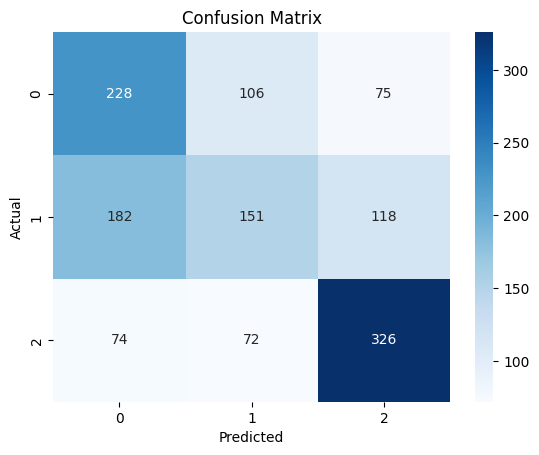

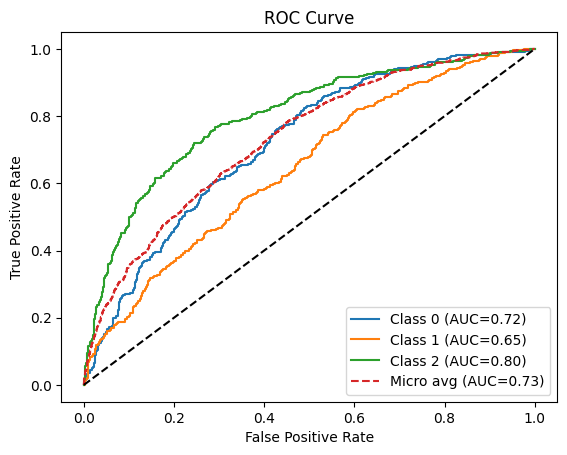

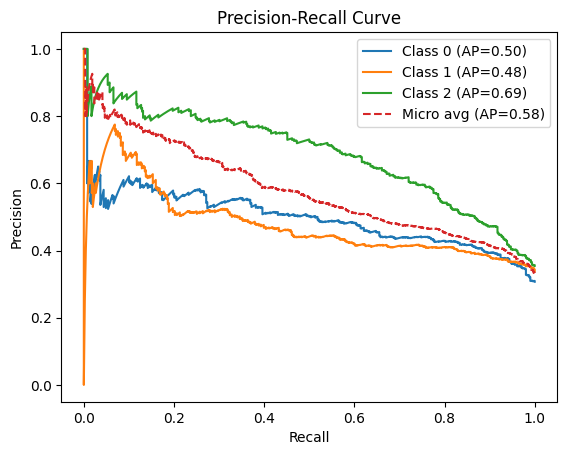

SHAP beeswarm for class 0


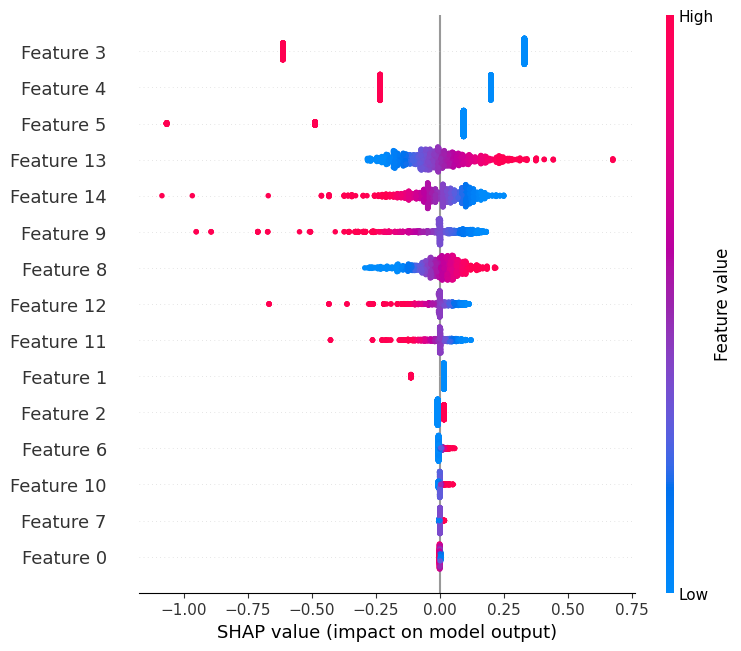

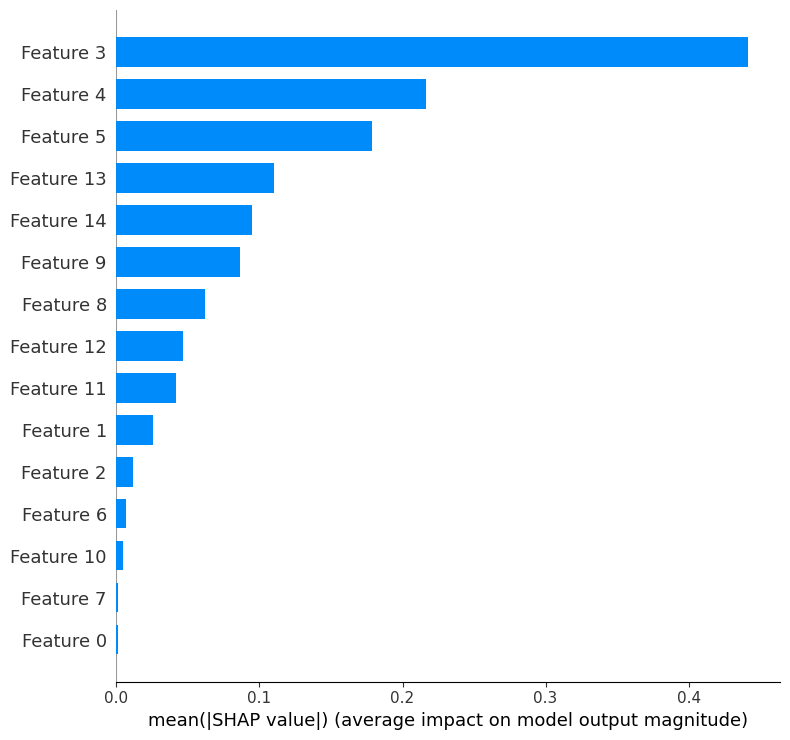

SHAP beeswarm for class 1


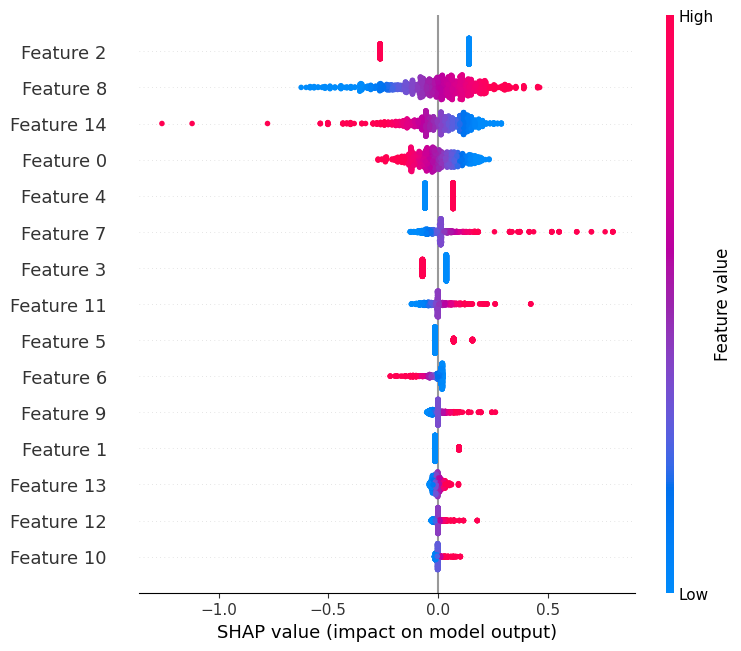

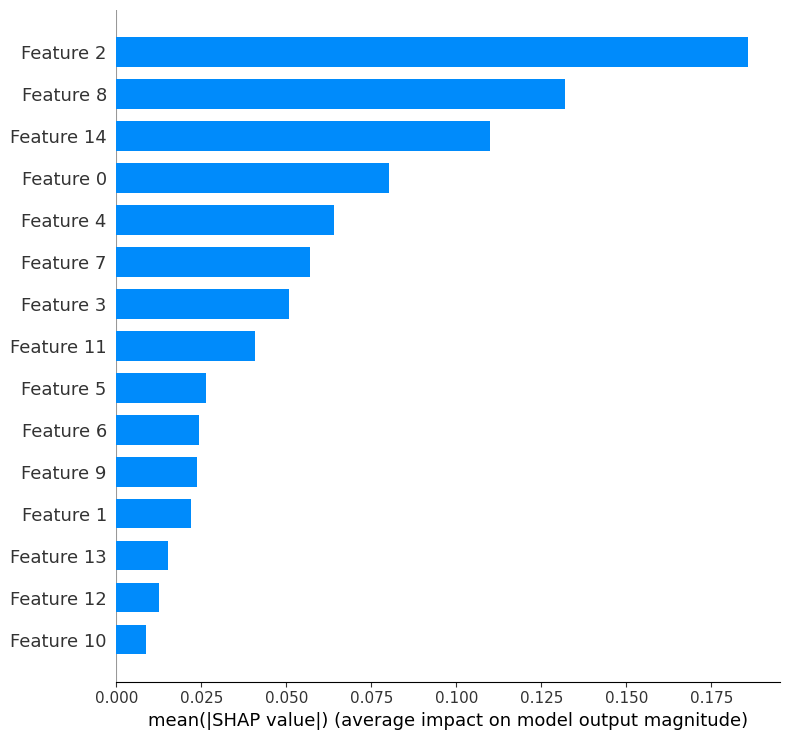

SHAP beeswarm for class 2


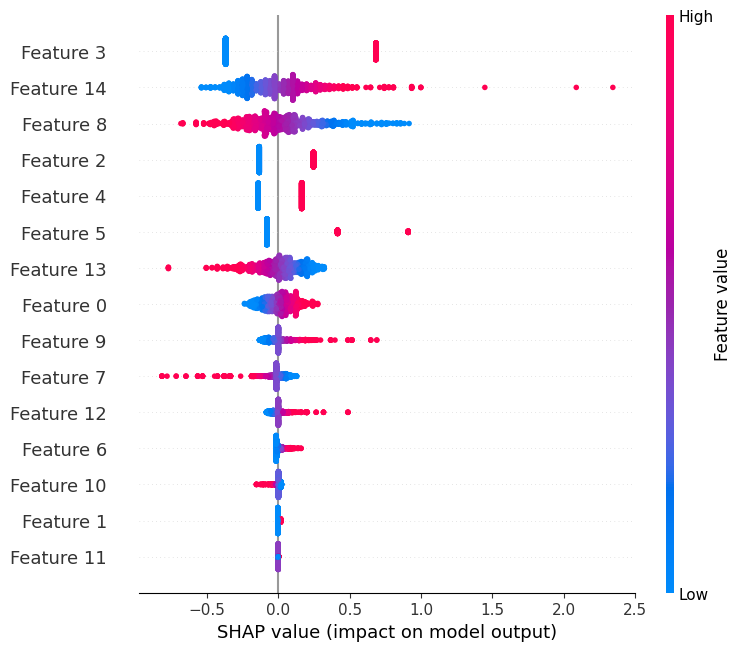

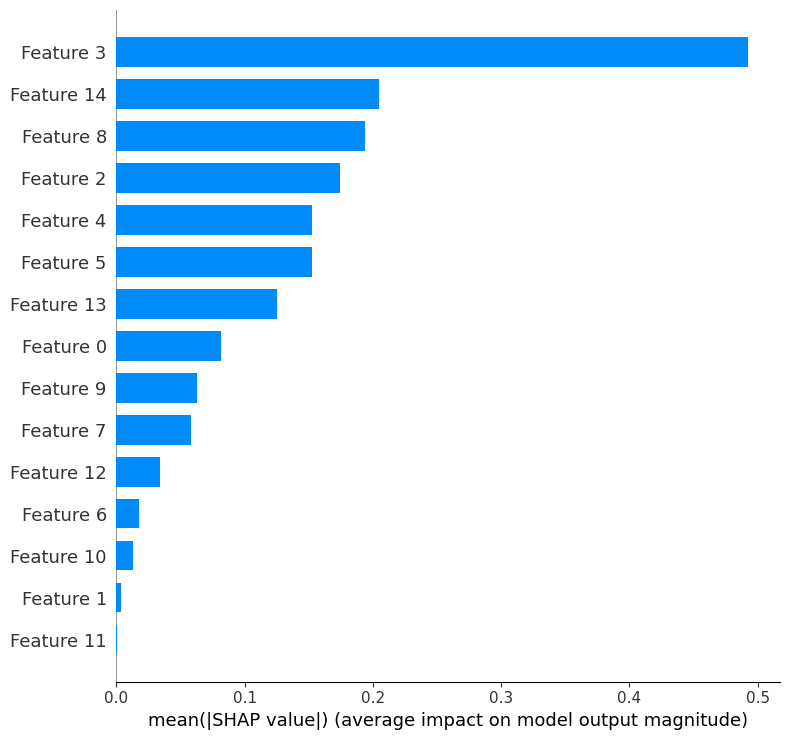


Random Forest:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       409
           1       0.82      0.85      0.84       451
           2       0.88      0.89      0.88       472

    accuracy                           0.85      1332
   macro avg       0.85      0.85      0.85      1332
weighted avg       0.85      0.85      0.85      1332

ROC-AUC (macro-ovr): 0.9519


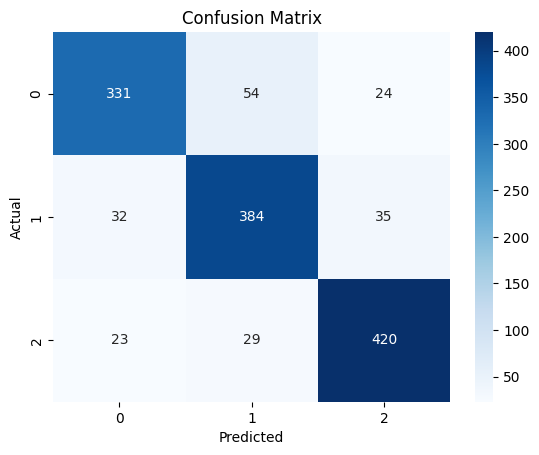

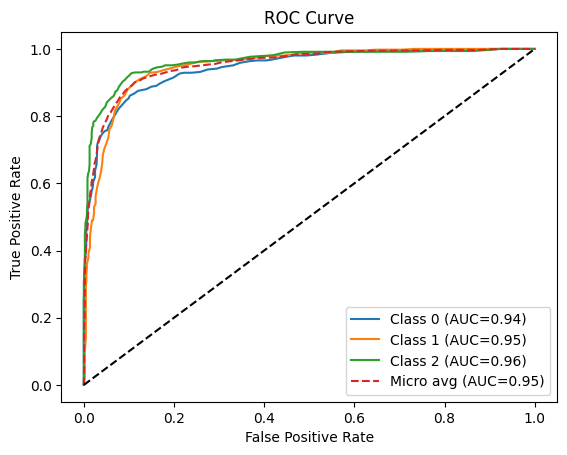

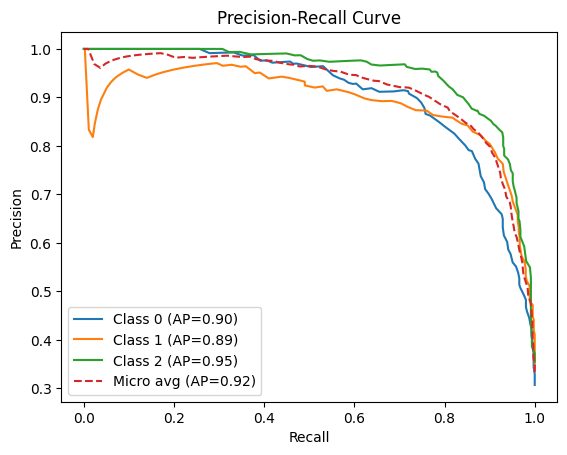

SHAP beeswarm for class 0


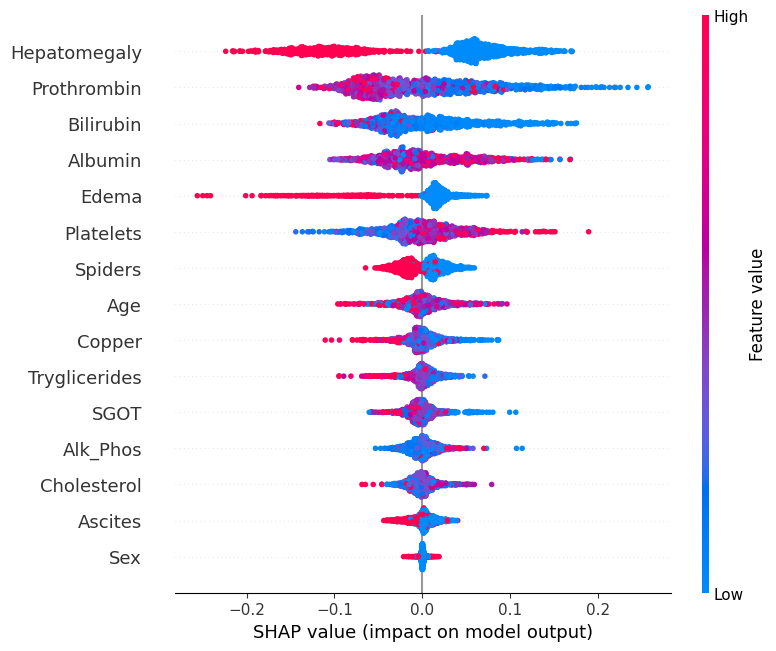

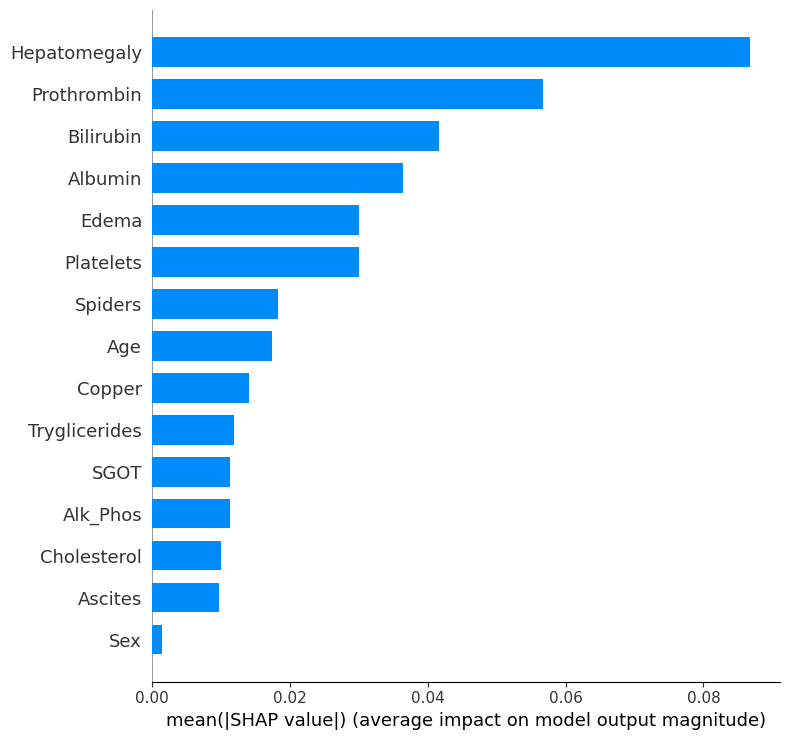

SHAP beeswarm for class 1


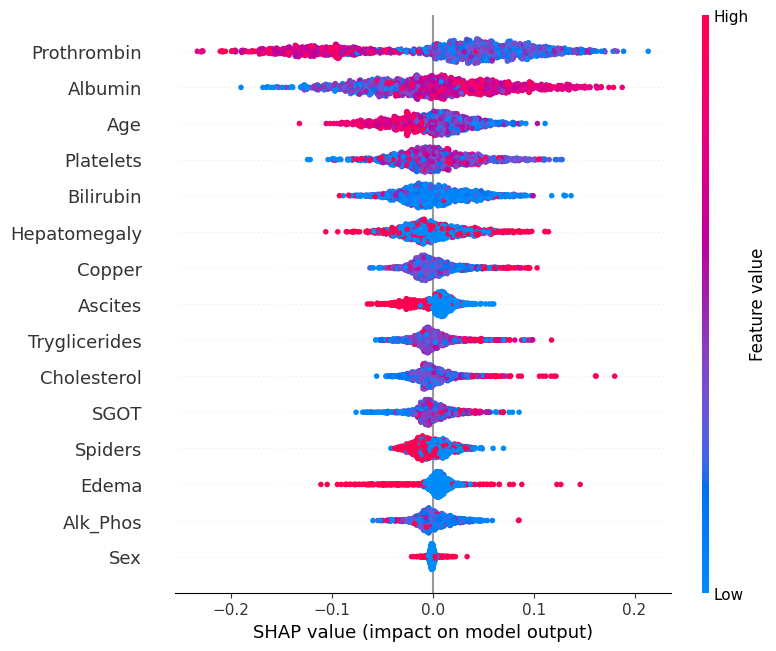

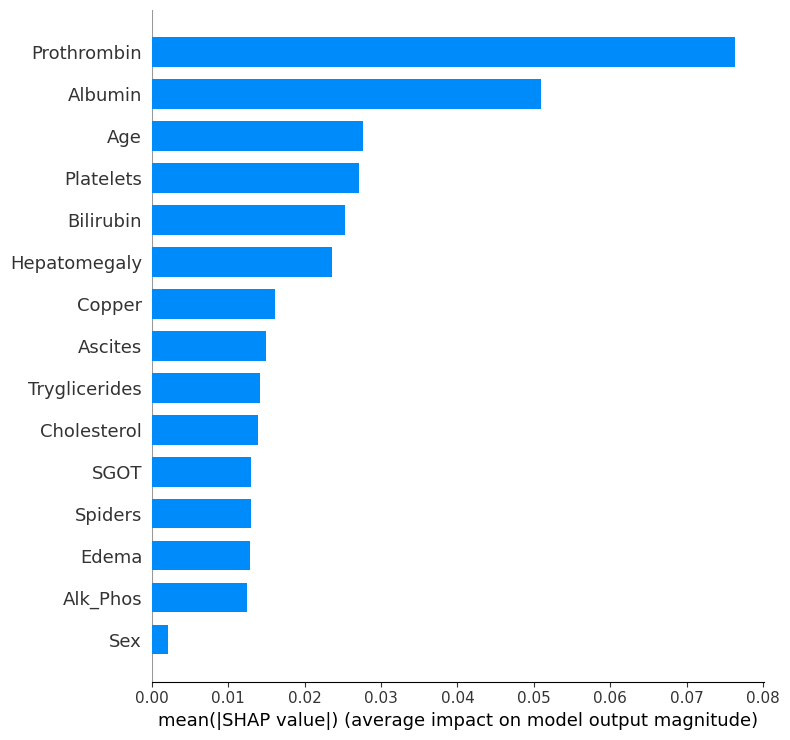

SHAP beeswarm for class 2


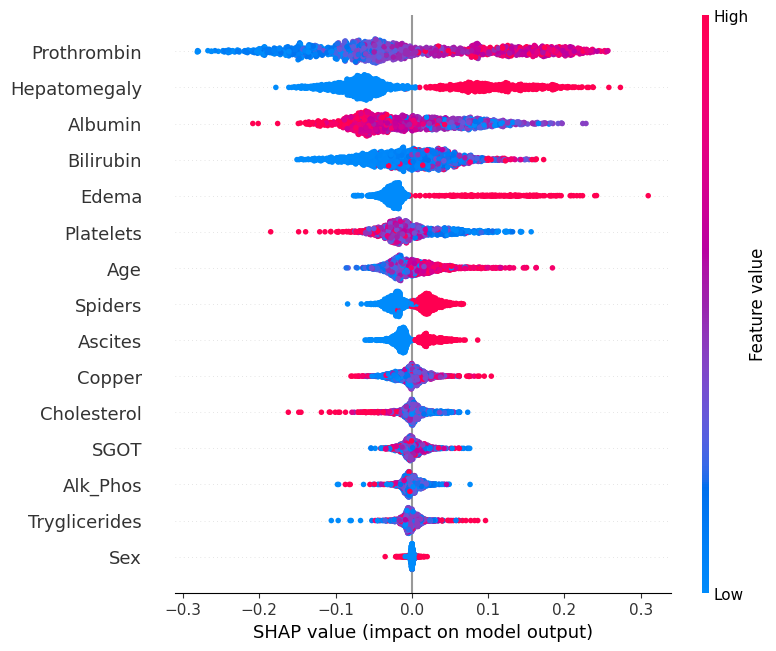

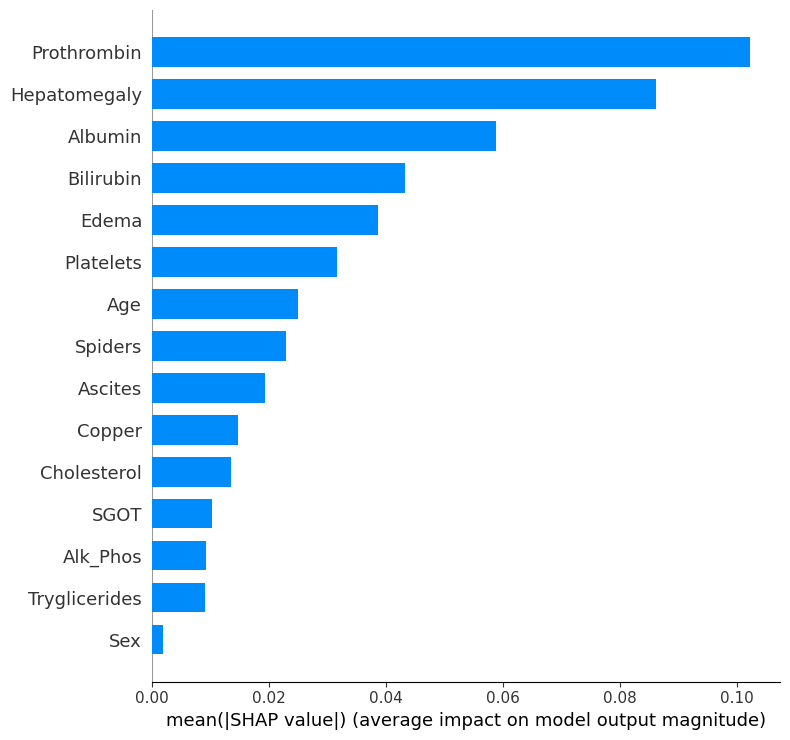


XGBoost:


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:32:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       409
           1       0.85      0.90      0.88       451
           2       0.93      0.90      0.91       472

    accuracy                           0.89      1332
   macro avg       0.89      0.89      0.89      1332
weighted avg       0.89      0.89      0.89      1332

ROC-AUC (macro-ovr): 0.9705


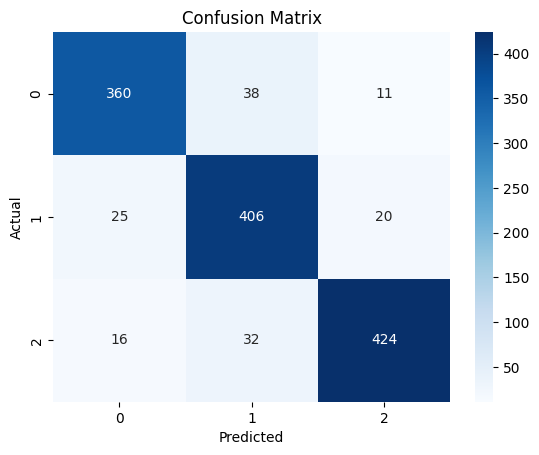

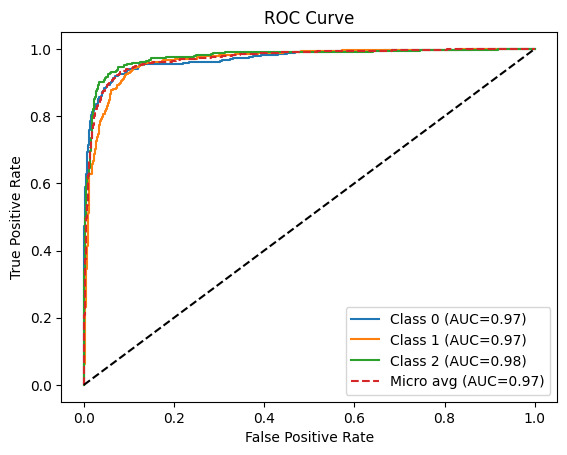

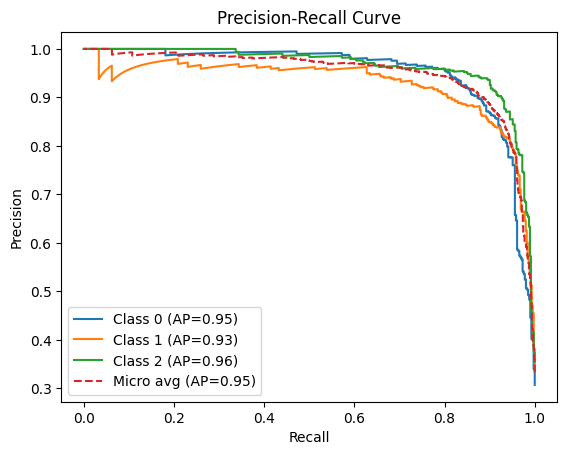

SHAP beeswarm for class 0


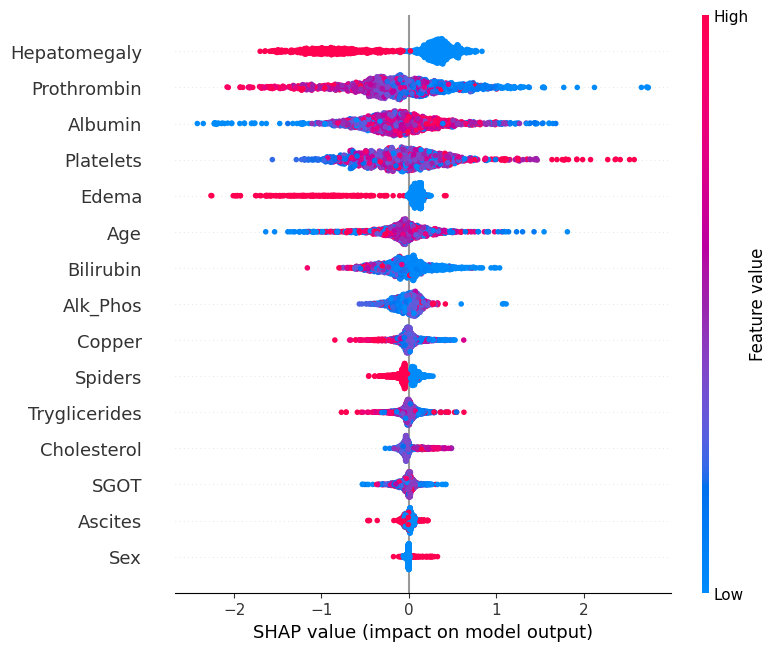

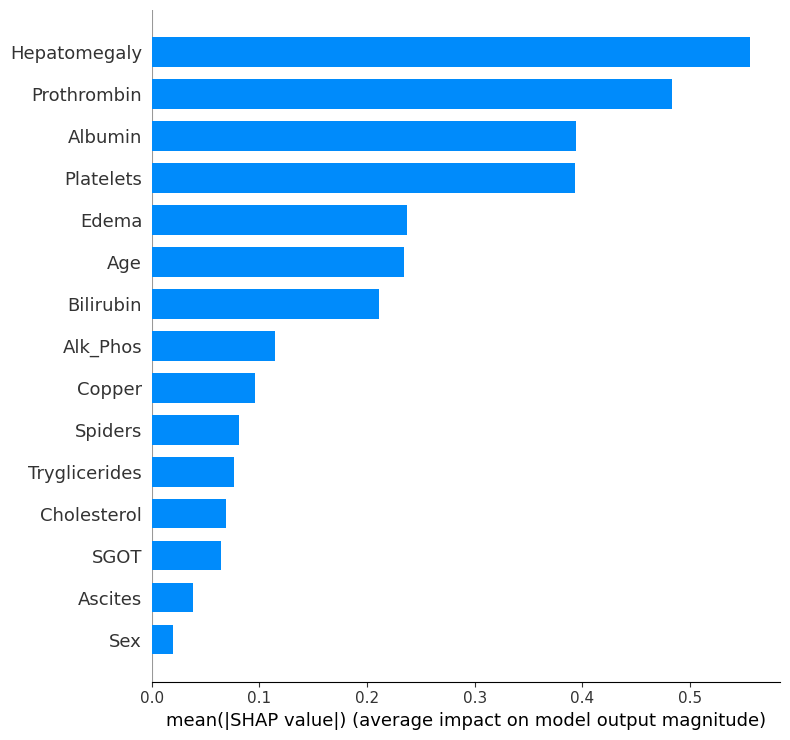

SHAP beeswarm for class 1


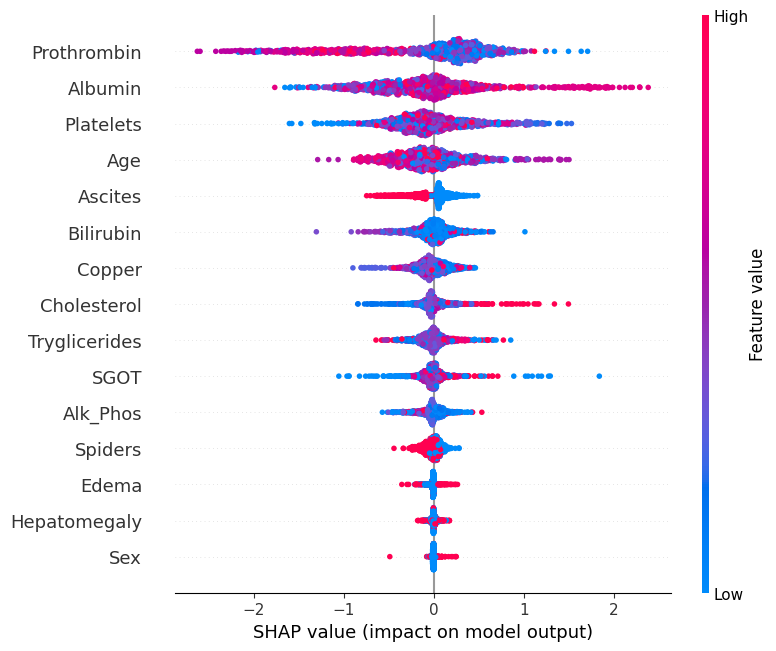

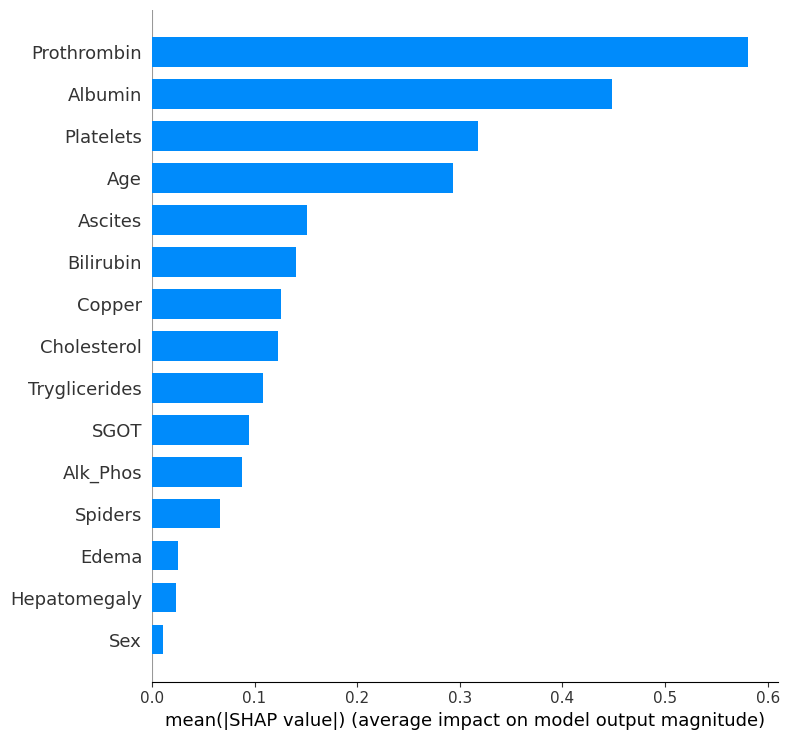

SHAP beeswarm for class 2


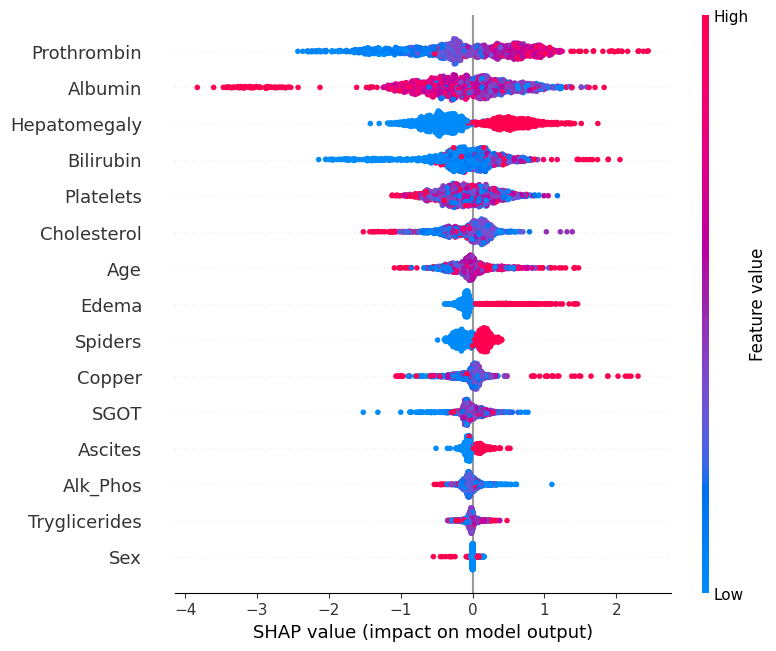

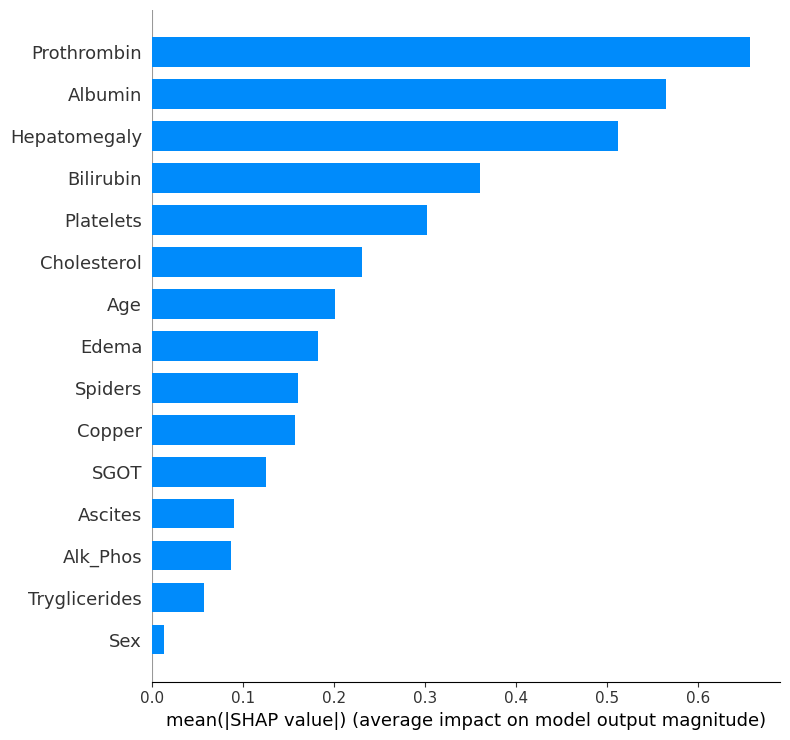

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# 3. SHAP plotting function
def plot_shap_beeswarm(model, X_tr, X_te, model_name, model_type):
    if model_type == "linear":
        explainer = shap.LinearExplainer(model, X_tr)
        shap_values = explainer(X_te)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_te)
    # For multiclass, plot for each class
    if hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
        n_classes = shap_values.shape[2]
        for i in range(n_classes):
            print(f"SHAP beeswarm for class {i}")          
            try:
                shap.plots.beeswarm(shap_values[:,:,i], max_display=15)
            except Exception as e:
                print(f"Beeswarm error: {e}")
            # Always also show a bar plot for clarity
            shap.summary_plot(shap_values[:,:,i], X_te, plot_type="bar")
    else:
        shap.plots.beeswarm(shap_values, max_display=10)


# 4. evaluation functions
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    
def plot_roc_pr_curves(y_true, y_score, n_classes):
    # Binarize labels
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y_true, classes=np.arange(n_classes))

    # ROC Curve
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure()
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC={roc_auc[i]:.2f})")
    plt.plot(fpr["micro"], tpr["micro"], label=f"Micro avg (AUC={roc_auc['micro']:.2f})", linestyle='--')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # PR Curve
    precision, recall, pr_auc = {}, {}, {}
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
        pr_auc[i] = average_precision_score(y_bin[:, i], y_score[:, i])

    precision["micro"], recall["micro"], _ = precision_recall_curve(y_bin.ravel(), y_score.ravel())
    pr_auc["micro"] = average_precision_score(y_bin, y_score, average="micro")

    plt.figure()
    for i in range(n_classes):
        plt.plot(recall[i], precision[i], label=f"Class {i} (AP={pr_auc[i]:.2f})")
    plt.plot(recall["micro"], precision["micro"], label=f"Micro avg (AP={pr_auc['micro']:.2f})", linestyle='--')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()   


## 5. Training, Evaluation, and SHAP
for name, model in models.items():
    print(f"\n{'='*30}\n{name}:")
    if name == "Logistic Regression":
        Xtr, Xte = X_train_scaled, X_test_scaled
        ytr, yte = y_train, y_test
        model_type = "linear"
    else:
        Xtr, Xte = X_train, X_test
        ytr, yte = y_train, y_test
        model_type = "tree"

    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    print(classification_report(yte, y_pred))

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(Xte)
        auc_macro = roc_auc_score(yte, y_proba, multi_class="ovr", average="macro")
        print(f"ROC-AUC (macro-ovr): {auc_macro:.4f}")

        # Extra evaluations
        plot_confusion_matrix(yte, y_pred, labels=np.unique(yte))
        plot_roc_pr_curves(yte, y_proba, n_classes=len(np.unique(yte)))

    # SHAP
    try:
        plot_shap_beeswarm(model, Xtr, Xte, name, model_type)
    except Exception as e:
        print(f"SHAP error for {name}: {e}")
